In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [49]:
CSV_PATH  = "final_GPCRs_and_accessory_Protiens/sctr_exon_coding_variants.csv"   # ← path to your file
GENE_NAME = "SCTR"

In [50]:
COLOR_MAP = {
    # Coding changes
    "missense_variant":                    "#7F77DD",   # purple
    "synonymous_variant":                  "#3DA876",   # green
    "stop_gained":                         "#E24B4A",   # red
    "stop_lost":                           "#B03A2E",   # dark red
    "start_lost":                          "#E8740C",   # orange-red
    "frameshift_variant":                  "#D4537E",   # pink
    "inframe_insertion":                   "#EF9F27",   # amber
    "inframe_deletion":                    "#C97B1A",   # dark amber
}
 
LABEL_MAP = {
    "missense_variant":                    "Missense",
    "synonymous_variant":                  "Synonymous",
    "stop_gained":                         "Stop gained",
    "stop_lost":                           "Stop lost",
    "start_lost":                          "Start lost",
    "frameshift_variant":                  "Frameshift",
    "inframe_insertion":                   "Inframe insertion",
    "inframe_deletion":                    "Inframe deletion",
}

In [51]:
df = pd.read_csv(CSV_PATH)
 
# Build a lowercase lookup to handle different capitalisation styles
col_lookup = {c.lower().strip(): c for c in df.columns}
 
def find_col(keywords):
    """Return the first column whose lowercased name contains any keyword."""
    for kw in keywords:
        for low, orig in col_lookup.items():
            if kw in low:
                return orig
    raise KeyError(f"Could not find a column matching: {keywords}\n"
                   f"Available: {list(df.columns)}")
 
COL_POSITION = find_col(["protein position", "protein_position"])
COL_AA       = find_col(["amino acid change", "amino acid"])
COL_CONS     = find_col(["conseq"])
COL_FREQ     = find_col(["allele freq", "allele frequency"])
COL_PVAL     = find_col(["p value", "pvalue"])
COL_LOGP     = find_col(["logp", "log p", "negative log"])
 
# Keep only coding rows (protein position is a number, not "-")
df = df[df[COL_POSITION].astype(str).str.strip() != "-"].copy()
df[COL_POSITION] = pd.to_numeric(df[COL_POSITION], errors="coerce")
df = df.dropna(subset=[COL_POSITION])
df[COL_POSITION] = df[COL_POSITION].astype(int)
 
# Simplify combo consequences
df[COL_CONS] = df[COL_CONS].astype(str).str.split(",").str[0].str.strip()
 
# Variant label: e.g. "Y/D332"
df["label"] = df[COL_AA].astype(str) + df[COL_POSITION].astype(str)
 
# Color and dot size (bigger = more significant)
df["color"]    = df[COL_CONS].map(COLOR_MAP).fillna("#AAAAAA")
df["dot_size"] = np.clip(df[COL_LOGP] * 40, 30, 300)
 
df = df.sort_values(COL_POSITION).reset_index(drop=True)

In [52]:
DOMAIN_PRESETS = {
    "FFAR1": [
        (1, 3,   "#F4C6A0", "N-term"),
        (4, 37,  "#A8DADC", "TM1"),
        (39, 69, "#A8C4E0", "TM2"),
        (75, 110,"#A8DADC", "TM3"),
        (119, 146,"#A8C4E0", "TM4"),
        (175, 211,"#A8DADC", "TM5"),
        (217, 250,"#A8C4E0", "TM6"),
        (255, 279,"#A8DADC", "TM7"),
        (295, 300,"#F4C6A0", "C-Tail"),
    ],

    "GLP1R": [
        (1, 146,   "#F4C6A0", "N-term"),
        (147, 170, "#A8DADC", "TM1"),
        (175, 200, "#A8C4E0", "TM2"),
        (208, 238, "#A8DADC", "TM3"),
        (247, 271, "#A8C4E0", "TM4"),
        (291, 328, "#A8DADC", "TM5"),
        (335, 373, "#A8C4E0", "TM6"),
        (379, 402, "#A8DADC", "TM7"),
        (409, 463, "#F4C6A0", "C-Tail"),
    ],

    "GLP2R": [
        (1, 166,   "#F4C6A0", "N-term"),
        (167, 190, "#A8DADC", "TM1"),
        (195, 220, "#A8C4E0", "TM2"),
        (228, 258, "#A8DADC", "TM3"),
        (267, 291, "#A8C4E0", "TM4"),
        (311, 348, "#A8DADC", "TM5"),
        (355, 393, "#A8C4E0", "TM6"),
        (399, 422, "#A8DADC", "TM7"),
        (429, 553, "#F4C6A0", "C-Tail"),
    ],

    "LPAR1": [
        (1, 17,    "#F4C6A0", "N-term"),
        (18, 48,   "#A8DADC", "TM1"),
        (59, 86,   "#A8C4E0", "TM2"),
        (97, 129,  "#A8DADC", "TM3"),
        (138, 163, "#A8C4E0", "TM4"),
        (183, 223, "#A8DADC", "TM5"),
        (229, 268, "#A8C4E0", "TM6"),
        (290, 318, "#A8DADC", "TM7"),
        (339, 364, "#F4C6A0", "C-Tail"),
    ],

    "MC4R": [
        (1, 49,    "#F4C6A0", "N-term"),
        (50, 76,   "#A8DADC", "TM1"),
        (82, 108,  "#A8C4E0", "TM2"),
        (117, 149, "#A8DADC", "TM3"),
        (158, 181, "#A8C4E0", "TM4"),
        (201, 240, "#A8DADC", "TM5"),
        (246, 285, "#A8C4E0", "TM6"),
        (292, 318, "#A8DADC", "TM7"),
        (329, 332, "#F4C6A0", "C-Tail"),
    ],

    "SCTR": [
        (1, 150,   "#F4C6A0", "N-term"),
        (151, 174, "#A8DADC", "TM1"),
        (179, 204, "#A8C4E0", "TM2"),
        (212, 242, "#A8DADC", "TM3"),
        (251, 275, "#A8C4E0", "TM4"),
        (295, 332, "#A8DADC", "TM5"),
        (339, 377, "#A8C4E0", "TM6"),
        (383, 406, "#A8DADC", "TM7"),
        (413, 440, "#F4C6A0", "C-Tail"),
    ],
}
# Use preset if available, otherwise draw a plain backbone only
DOMAINS = DOMAIN_PRESETS.get(GENE_NAME.upper(), [])
 

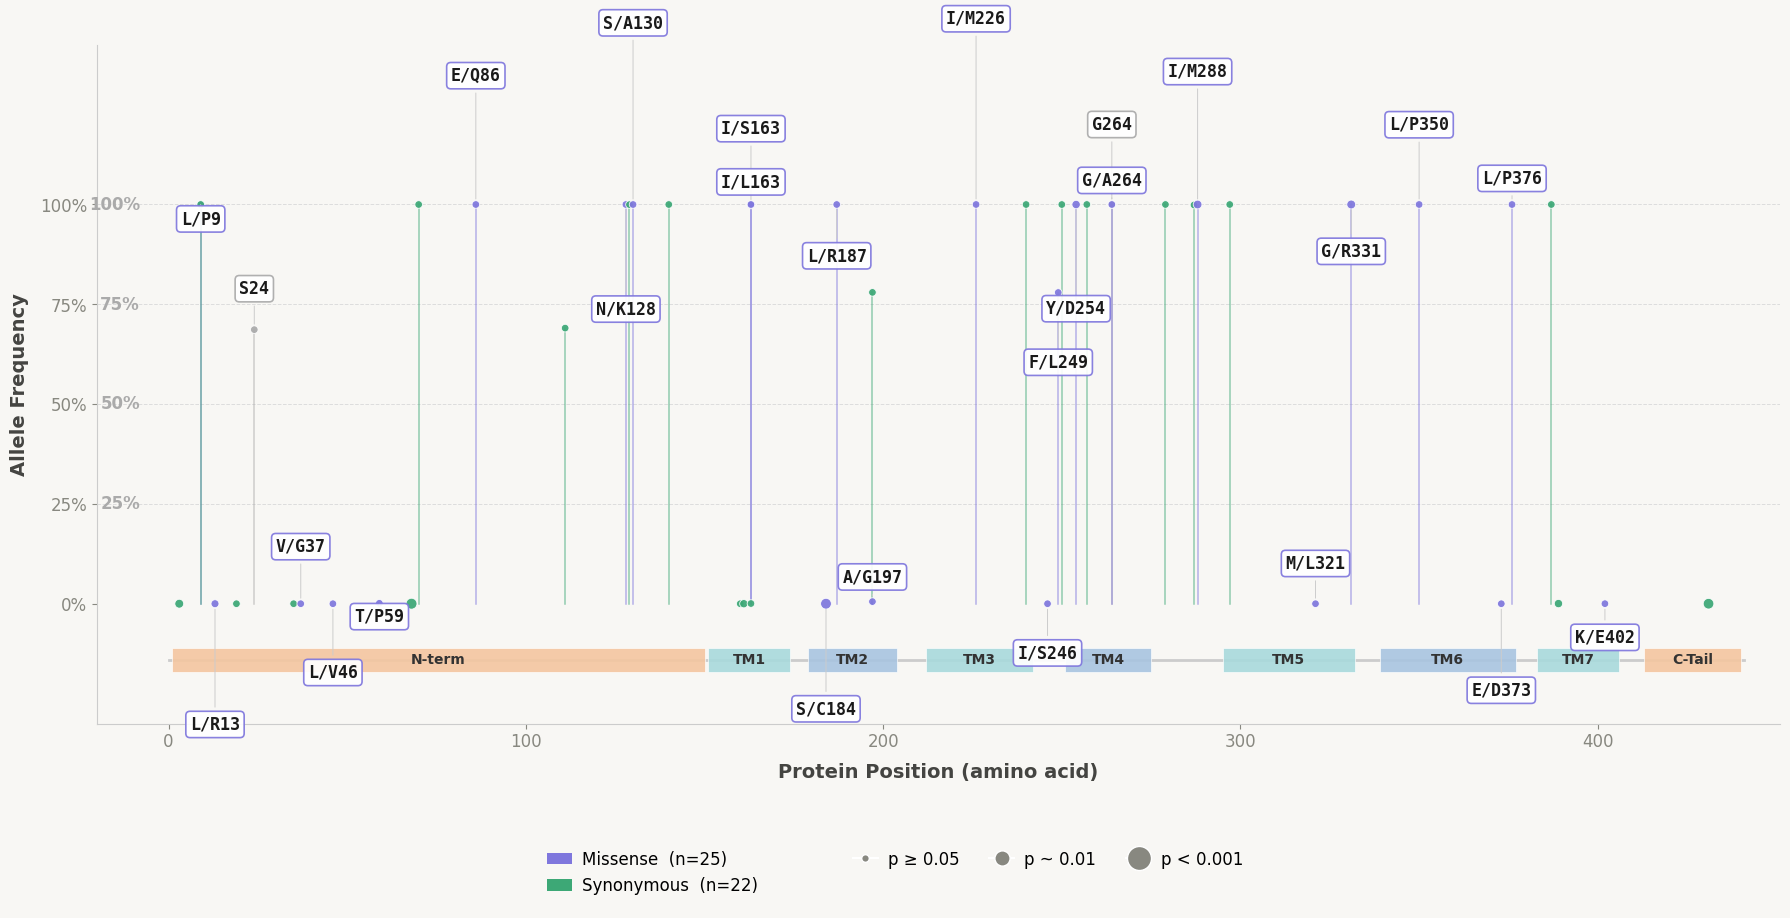

Saved: sctr_lollipop.png


In [53]:
max_pos = df[COL_POSITION].max()
 
fig, ax = plt.subplots(figsize=(18, 8), facecolor="#F8F7F4")
ax.set_facecolor("#F8F7F4")
 
# ── Domain track ─────────────────────────────────────────────
DOMAIN_Y = -0.14
DOMAIN_H = 0.06
 
# Plain backbone line (always shown)
ax.plot([0, max_pos + 10], [DOMAIN_Y, DOMAIN_Y],
        color="#CCCCCC", lw=2, zorder=1)
 
# Colored domain blocks
for (start, end, col, dname) in DOMAINS:
    ax.barh(DOMAIN_Y, end - start, left=start,
            height=DOMAIN_H, color=col, alpha=0.9,
            linewidth=0.5, edgecolor="white", zorder=2)
    ax.text((start + end) / 2, DOMAIN_Y, dname,
            ha="center", va="center",
            fontsize=10, fontweight="bold", color="#333333", zorder=3) # Increased to 10 & explicitly "bold"
 
# ── Frequency grid lines ─────────────────────────────────────
for y, label in [(0.25, "25%"), (0.50, "50%"), (0.75, "75%"), (1.00, "100%")]:
    ax.axhline(y, color="#DDDDDD", lw=0.7, ls="--", zorder=0)
    ax.text(-8, y, label, ha="right", va="center",
            fontsize=12, fontweight="bold", color="#AAAAAA") # Increased to 12 & bold
 
# ── Lollipop stems ────────────────────────────────────────────
for _, row in df.iterrows():
    ax.plot(
        [row[COL_POSITION], row[COL_POSITION]],
        [0, row[COL_FREQ]],
        color=row["color"], lw=1.1, alpha=0.55, zorder=1
    )
 
# ── Dots (size = significance) ────────────────────────────────
ax.scatter(
    df[COL_POSITION], df[COL_FREQ],
    c=df["color"], s=df["dot_size"],
    edgecolors="white", linewidths=0.6,
    zorder=4, alpha=0.93
)
 
# ── Labels — PRESENTATION TUNING VIA SPRING RELAXATION ────────────
#
# Adjusted for larger fonts to ensure the relaxation algorithm spreads them cleanly
LABEL_FS     = 12.0   # PRESENTATION CHANGE: Bumped from 7.5 to 12.0
LABEL_HEIGHT = 0.10   # PRESENTATION CHANGE: Increased approx label height allowance
LABEL_WIDTH  = 85     # PRESENTATION CHANGE: Increased horizontal protection window from 55 to 85
MIN_SEP      = LABEL_HEIGHT * 1.3   # PRESENTATION CHANGE: Scaled up minimum vertical gap
DOT_OFFSET   = 0.08   # PRESENTATION CHANGE: Slightly increased initial launch offset from dot
 
# Only label non-synonymous variants to keep the plot clean
label_df   = df[df[COL_CONS] != "synonymous_variant"].copy()
 
# Split into top (above) and bottom (below) groups
top_idx    = label_df[label_df[COL_FREQ] >  0.5].index.tolist()
bottom_idx = label_df[label_df[COL_FREQ] <= 0.5].index.tolist()
 
def spread_labels(indices, direction):
    """
    Iteratively push labels apart so none overlap.
    direction = +1 → labels above dots
    direction = -1 → labels below dots
    Returns {index: y_position} for each label.
    """
    if not indices:
        return {}
 
    # Start each label just offset from its dot
    positions   = {i: df.loc[i, COL_FREQ] + direction * DOT_OFFSET
                   for i in indices}
    sorted_idx  = sorted(indices, key=lambda i: df.loc[i, COL_POSITION])
 
    for _ in range(300):                        # max iterations
        moved = False
        for a in range(len(sorted_idx)):
            for b in range(a + 1, len(sorted_idx)):
                ia, ib = sorted_idx[a], sorted_idx[b]
                xa, xb = df.loc[ia, COL_POSITION], df.loc[ib, COL_POSITION]
                ya, yb = positions[ia], positions[ib]
 
                # Only interact if horizontally close enough to collide
                if abs(xa - xb) > LABEL_WIDTH:
                    continue
 
                overlap = MIN_SEP - abs(yb - ya)
                if overlap > 0:
                    push = overlap / 2 + 0.005
                    # Push the pair apart in the correct direction
                    if (direction == 1 and yb >= ya) or (direction == -1 and yb <= ya):
                        positions[ib] += direction * push
                        positions[ia] -= direction * push
                    else:
                        positions[ia] += direction * push
                        positions[ib] -= direction * push
                    moved = True
        if not moved:
            break                               # converged early
 
    return positions
 
top_pos  = spread_labels(top_idx,    direction=+1)
bot_pos  = spread_labels(bottom_idx, direction=-1)
all_pos  = {**top_pos, **bot_pos}
 
# Draw connector line + label box for non-synonymous variants only
for i, row in label_df.iterrows():
    dot_x  = row[COL_POSITION]
    dot_y  = row[COL_FREQ]
    lbl_y  = all_pos[i]
    col    = row["color"]
    va     = "bottom" if lbl_y > dot_y else "top"
 
    # Thin grey connector from dot to label
    ax.annotate(
        "",
        xy=(dot_x, dot_y),
        xytext=(dot_x, lbl_y),
        arrowprops=dict(arrowstyle="-", color="#CCCCCC",
                        lw=0.7, shrinkA=6, shrinkB=4),
        zorder=5
    )
    # Label with colored border
    ax.text(
        dot_x, lbl_y, row["label"],
        ha="center", va=va,
        fontsize=LABEL_FS, color="#1A1A1A",
        fontfamily="monospace", fontweight="bold", # PRESENTATION CHANGE: Explicitly "bold" instead of "500"
        bbox=dict(boxstyle="round,pad=0.25", fc="white",
                  ec=col, alpha=0.92, lw=1.2),     # Slightly thicker border box line
        zorder=6
    )
 
# ── Axes formatting ───────────────────────────────────────────
ax.set_xlim(-20, max_pos + 20)
ax.set_ylim(-0.30, 1.40)
ax.set_xlabel("Protein Position (amino acid)", fontsize=14, fontweight="bold", color="#444441", labelpad=8) # Increased to 14 & bold
ax.set_ylabel("Allele Frequency",              fontsize=14, fontweight="bold", color="#444441", labelpad=8) # Increased to 14 & bold
# ax.set_title(
#     f"{GENE_NAME}\n"
#     "Allele Frequency × Protein Position  |  dot size = significance (−log p)",
#     fontsize=18, fontweight="bold", color="#2C2C2A", pad=14 # Increased title size to 18 & bold
# )
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")
ax.tick_params(colors="#888880", labelsize=12) # PRESENTATION CHANGE: Tick size from 9 to 12
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
 
# =============================================================
#  STEP 4 — Legend at the bottom (consequence colors + dot sizes)
# =============================================================
# Consequence color patches — only types present in this file
color_handles = [
    mpatches.Patch(
        facecolor=COLOR_MAP.get(c, "#AAAAAA"), edgecolor="none",
        label=f"{LABEL_MAP.get(c, c)}  (n={(df[COL_CONS] == c).sum()})"
    )
    for c in COLOR_MAP
    if (df[COL_CONS] == c).sum() > 0
]
 
# Dot size guide
size_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#888880", markeredgecolor="white",
           markersize=np.sqrt(s),
           label=lbl)
    for s, lbl in [(30, "p ≥ 0.05"), (120, "p ~ 0.01"), (300, "p < 0.001")]
]
 
# Combine both into one legend below the plot
all_handles = color_handles + [
    Line2D([0], [0], color="none", label="")   # spacer
] + size_handles
 
fig.legend(
    handles=all_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15), # Pushed slightly lower down to account for larger axis label dimensions
    ncol=min(5, len(color_handles) + 1 + len(size_handles)),
    frameon=False,
    fontsize=12,                 # PRESENTATION CHANGE: Legend font size from 9 to 12
    handlelength=1.5,
    handletextpad=0.6,
    columnspacing=1.8,
    borderpad=0.8,
)
 
# =============================================================
#  STEP 5 — Save
# =============================================================
plt.tight_layout()
output_file = f"{GENE_NAME.lower()}_lollipop.png"
plt.savefig(output_file, dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {output_file}")